<a href="https://colab.research.google.com/github/AyushiB56/Neural-Network/blob/main/dropout.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import torch.nn as nn
import torch
import numpy as np
import matplotlib.pyplot as plt
from IPython import display
display.set_matplotlib_formats('svg')
import torch.nn.functional as F

#It sets the output format of Matplotlib plots in Jupyter/IPython notebooks to SVG (Scalable Vector Graphics) instead of the default PNG.


from torch.utils.data import TensorDataset, DataLoader

import numpy as np


<ipython-input-3-d596777a1555>:6: DeprecationWarning: `set_matplotlib_formats` is deprecated since IPython 7.23, directly use `matplotlib_inline.backend_inline.set_matplotlib_formats()`
  display.set_matplotlib_formats('svg')


🧠 Why Use cos(th) and sin(th)?
These are parametric equations for a circle in 2D space:

𝑥
=
𝑟
⋅
cos
⁡
(
𝜃
)
𝑦
=
𝑟
⋅
sin
⁡
(
𝜃
)
x=r⋅cos(θ)
y=r⋅sin(θ)
θ (theta) is the angle in radians

r is the radius of the circle

When you vary θ from 0 to 2π, the point (x, y) traces a circle.

In [4]:
import numpy as np
import matplotlib.pyplot as plt

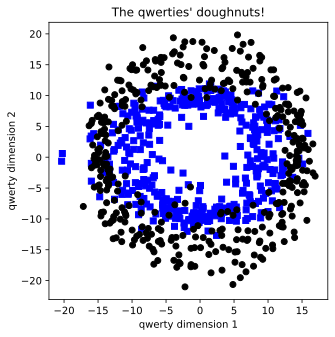

In [5]:
no_of_dp= 400

# np.linspace() is a very commonly used function in NumPy for generating evenly spaced values over a specified range.
theta = np.linspace(0, 4*np.pi, no_of_dp)
r1=10
r2=15


# first circle

# a=[r1*np.cos(theta)+np.random.randn(no_of_dp)*3,
#    r1*np.sin(theta)+np.random.randn(no_of_dp)

#    ]
# b=[r2*np.cos(theta)+np.random.randn(no_of_dp),r2*np.sin(theta)+np.random.randn(no_of_dp)*3]

# generate data
a = [ r1*np.cos(theta) + np.random.randn(no_of_dp)*3 ,
      r1*np.sin(theta) + np.random.randn(no_of_dp) ]
b = [ r2*np.cos(theta) + np.random.randn(no_of_dp) ,
      r2*np.sin(theta) + np.random.randn(no_of_dp)*3 ]

#np.zeros((nPerClust, 1))
#That means:

#“Create a 2D array with nPerClust rows and 1 column”

labels = np.vstack((np.zeros((no_of_dp,1)),np.ones((no_of_dp,1))))
data= np.hstack((a,b)).T

data = torch.tensor(data).float()
labels = torch.tensor(labels).float()




fig= plt.figure(figsize=(5,5))
plt.plot(data[np.where(labels==0)[0], 0], data[np.where(labels==0)[0], 1], 'bs') # b= blue and s=square
plt.plot(data[np.where(labels==1)[0], 0], data[np.where(labels==1)[0], 1], 'ko')# k = black and o= circle
plt.title("The qwerties' doughnuts!")
plt.xlabel('qwerty dimension 1')
plt.ylabel('qwerty dimension 2')
plt.show()

In [6]:
data.shape

torch.Size([800, 2])

In [7]:
data.shape

torch.Size([800, 2])

the dataset is created , now with split the data

In [8]:
from sklearn.model_selection import train_test_split

In [9]:
X_train,x_test,y_train,y_test= train_test_split(data, labels, test_size=0.2)

In [10]:
X_train.shape

torch.Size([640, 2])

In [11]:
X_train_tensor = TensorDataset(X_train,y_train)
X_test_tensor = TensorDataset(x_test,y_test)

In [12]:
x_y_loader_train= DataLoader(X_train_tensor, batch_size=32,shuffle=True,drop_last= True)

In [13]:
x_y_loader_test= DataLoader(X_test_tensor, batch_size=32,shuffle=True,drop_last= True)

In [14]:
X_train

tensor([[-14.9130,   0.7464],
        [-13.8955,   0.7649],
        [  6.7749,   5.1970],
        ...,
        [ 13.4364,  -7.9316],
        [-13.8641,   3.6098],
        [ 10.1191,  -9.7013]])

In [15]:
len(x_y_loader_train)

20

In [16]:
#x[21] accesses the 22nd sample in the batch (Python is zero-indexed)

[x[31] for x,y in x_y_loader_train]# x[32] accesses the 32nd sample in the batch (Python is zero-indexed)

[tensor([-5.8663, 11.8295]),
 tensor([10.0617, -4.1370]),
 tensor([-8.4061,  5.9947]),
 tensor([13.2138,  3.3657]),
 tensor([-14.1039,  -1.3469]),
 tensor([-16.1747,   2.9722]),
 tensor([  8.8022, -13.5881]),
 tensor([-10.4632,  11.7101]),
 tensor([-14.7535,  -6.4158]),
 tensor([-11.0442,   8.2527]),
 tensor([-2.2394, -8.6476]),
 tensor([ 3.3300, -8.5368]),
 tensor([14.5950,  2.0792]),
 tensor([ 7.7512, 10.7487]),
 tensor([ -1.6681, -10.3009]),
 tensor([-9.0516,  4.7077]),
 tensor([11.9071,  7.6823]),
 tensor([ -6.1376, -11.5742]),
 tensor([-13.2187,  -1.9161]),
 tensor([-8.9154, -4.2698])]

In [17]:
#first batch
[x.shape[0] for x,y in x_y_loader_train][0]

32

In [21]:
class Neural_Network(nn.Module):
  def __init__(self, dropout=0):
    super().__init__()

    self.layer1= nn.Linear(2,128)
    self.hidden =nn.Linear(128,60)
    self.output=nn.Linear(60,1)
    self.dropout = dropout


  def forward(self,x):
    x= torch.relu(self.layer1(x))
    x= F.dropout(x, p=self.dropout, training = self.training)
    x= torch.relu(self.hidden(x))
    x= F.dropout(x, p=self.dropout, training = self.training)
    x= torch.sigmoid(self.output(x))

    return x



def create_model(dropoutRate=0):
    model = Neural_Network(dropout= dropoutRate)
    Loss = nn.BCELoss()
    optimizer= torch.optim.Adam(model.parameters(), lr=0.001)
    return model,Loss, optimizer








In [19]:
model = Neural_Network(0.2)

In [25]:

x= torch.tensor(np.random.randn(2),dtype= torch.float)

In [26]:
x

tensor([-0.9213, -0.4215])

In [27]:
dropoutRate=np.random.randn(10)

In [28]:
dropoutRates = np.arange(10)/10

In [29]:
dropoutRates

array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9])

In [30]:
model = Neural_Network(dropout= 0.2)

In [31]:
import numpy as np

In [56]:
def Train_data():
  nepochs= 100
  dropoutRates = np.arange(10)/10
  loss_train=[]

  loss_test=[]
  result = np.zeros((len(dropoutRates),2))
  result_test = np.zeros((len(dropoutRates),2))


  for i,rates in enumerate(dropoutRates):
    model, loss, optimizer= create_model(rates)


    for epoch in range(nepochs):
      loss_train_epoch=[]
      loss_test_epoch=[]

      for x,y in x_y_loader_train:
          model.train()
          loss_list_batch=[]
          y_hat= model(x)
          loss_fn= loss(y_hat,y)

          optimizer.zero_grad()
          loss_fn.backward()
          optimizer.step()
          loss_list_batch.append(loss_fn.item())
      loss_train_epoch.append(np.mean(loss_list_batch))

      model.eval()
      with torch.no_grad():
        for x,y in x_y_loader_test:
          loss_test_batch=[]
          y_hat= model(x)
          loss_fn_test= loss(y_hat,y)
          loss_test_batch.append(loss_fn_test)
        loss_test_epoch.append(np.mean(loss_test_batch))


    result[i,0]=np.mean(loss_train_epoch[-50:])
    result[i,1]=np.mean(loss_test_epoch[-50:])










  return result,dropoutRates



In [42]:
def Train_data_no_dropout():
  nepochs= 100

  loss_train=[]

  loss_test=[]



  model, loss, optimizer= create_model()
  loss_train_epoch=[]
  loss_test_epoch=[]


  for epoch in range(nepochs):


      for x,y in x_y_loader_train:
          model.train()
          loss_list_batch=[]
          y_hat= model(x)
          loss_fn= loss(y_hat,y)

          optimizer.zero_grad()
          loss_fn.backward()
          optimizer.step()
          loss_list_batch.append(loss_fn.item())
      loss_train_epoch.append(np.mean(loss_list_batch))

      model.eval()
      with torch.no_grad():
        for x,y in x_y_loader_test:
          loss_test_batch=[]
          y_hat= model(x)
          loss_fn_test= loss(y_hat,y)
          loss_test_batch.append(loss_fn_test)
        loss_test_epoch.append(np.mean(loss_test_batch))













  return loss_train_epoch,loss_test_epoch



In [57]:
loss_train_epoch,loss_test_epoch=Train_data_no_dropout()

In [59]:
result,dropoutRates=Train_data()

In [49]:
loss_train_epoch=[x.item() for x in loss_train_epoch]
loss_test_epoch=[x.item() for x in loss_test_epoch]

In [51]:

# create a 1D smoothing filter
def smooth(x,k=5):
  return np.convolve(x,np.ones(k)/k,mode='same')


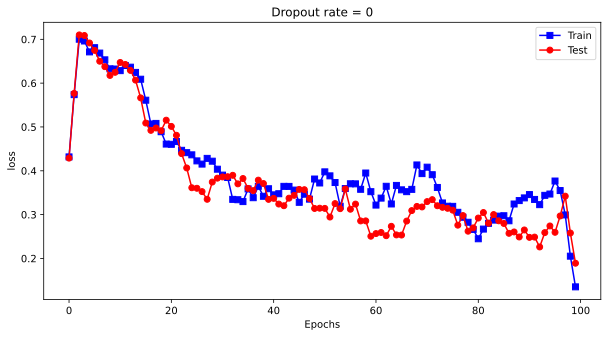

In [54]:
# plot the results
dropoutrate=0.0
fig = plt.figure(figsize=(10,5))

plt.plot(smooth(loss_train_epoch),'bs-')
plt.plot(smooth(loss_test_epoch),'ro-')
plt.xlabel('Epochs')
plt.ylabel('loss')
plt.legend(['Train','Test'])
plt.title('Dropout rate = %g'%dropoutrate)

plt.show()


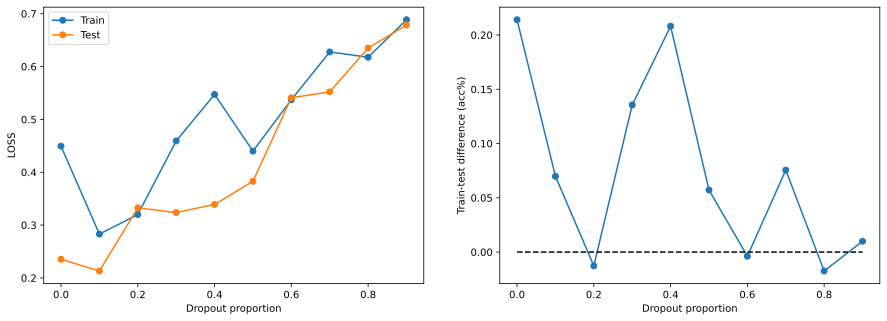

In [60]:
# plot the experiment results
fig,ax = plt.subplots(1,2,figsize=(15,5))

ax[0].plot(dropoutRates,result,'o-')
ax[0].set_xlabel('Dropout proportion')
ax[0].set_ylabel('LOSS')
ax[0].legend(['Train','Test'])

ax[1].plot(dropoutRates,-np.diff(result,axis=1),'o-')
ax[1].plot([0,.9],[0,0],'k--')
ax[1].set_xlabel('Dropout proportion')
ax[1].set_ylabel('Train-test difference (acc%)')

plt.show()